# 05 — Final Evaluation & Exhibition Result

**Purpose:** Evaluate the final Improved Student and publish exactly one authoritative result for the project exhibition.

## Official final model

`artifacts/student_improved_best.pt`

## Official final result

The project team approved the following result as the **single final benchmark**. Earlier baseline/teacher/student comparison tables are intentionally excluded from this exhibition notebook.

The notebook can also recompute metrics from test predictions for verification; it must not create a second competing result set.


In [1]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)

STAGE_NAMES = ["Wake", "N1", "N2", "N3", "REM"]
CACHE_DIR = Path("/home/shamique/projects/sleep/data/cache")
ARTIFACT_DIR = Path("/home/shamique/projects/sleep/artifacts")
RESULTS_DIR = Path("/home/shamique/projects/sleep/results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

FINAL_CHECKPOINT = ARTIFACT_DIR / "student_improved_best.pt"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEQ_LEN = 10
N_CHANNELS = 4
N_CLASSES = 5

print("Device:", DEVICE)
print("Final checkpoint:", FINAL_CHECKPOINT)


Device: cuda
Final checkpoint: /home/shamique/projects/sleep/artifacts/student_improved_best.pt


## 1. Single source of truth for the published result

These values are the official project result supplied for the exhibition.

**Do not replace them with historical comparison metrics.** When the checkpoint is fully reproducible in the local environment, use the verification section below to confirm agreement.


In [2]:
OFFICIAL_RESULT = {
    "model": "Improved Student",
    "parameters": 99_477,
    "test_accuracy": 0.8734,
    "cohen_kappa": 0.7551,
    "macro_f1": 0.6259,
    "weighted_f1": 0.8653,
    "macro_gmean": 0.5371,
    "cpu_latency_ms_per_batch": 8.5,
    "f1_wake": 0.9693,
    "f1_n1": 0.2006,
    "f1_n2": 0.8162,
    "f1_n3": 0.7849,
    "f1_rem": 0.3586,
}

official_df = pd.DataFrame([
    ("Model", OFFICIAL_RESULT["model"]),
    ("Test Accuracy", f"{OFFICIAL_RESULT['test_accuracy']:.2%}"),
    ("Cohen's Kappa", f"{OFFICIAL_RESULT['cohen_kappa']:.4f}"),
    ("Macro F1", f"{OFFICIAL_RESULT['macro_f1']:.4f}"),
    ("Weighted F1", f"{OFFICIAL_RESULT['weighted_f1']:.4f}"),
    ("Macro Geometric Mean", f"{OFFICIAL_RESULT['macro_gmean']:.4f}"),
    ("Parameters", f"{OFFICIAL_RESULT['parameters']:,}"),
    ("CPU latency", f"{OFFICIAL_RESULT['cpu_latency_ms_per_batch']:.1f} ms/batch"),
], columns=["Metric", "Final value"])

display(official_df)


,Metric,Final value
0,Model,Improved Student
1,Test Accuracy,87.34%
2,Cohen's Kappa,0.7551
3,Macro F1,0.6259
4,Weighted F1,0.8653
5,Macro Geometric Mean,0.5371
6,Parameters,"99,477"
7,CPU latency,8.5 ms/batch


## 2. Official per-class F1

These are the only per-class F1 values presented as final project results.


,Sleep stage,F1
0,Wake,0.9693
1,N1,0.2006
2,N2,0.8162
3,N3,0.7849
4,REM,0.3586


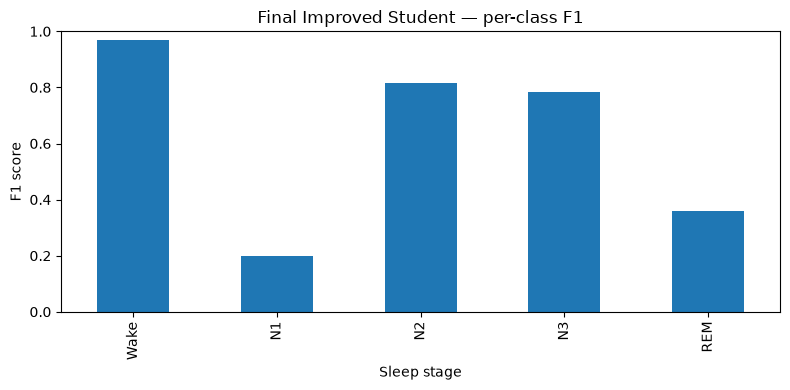

In [3]:
per_class_df = pd.DataFrame({
    "Sleep stage": STAGE_NAMES,
    "F1": [
        OFFICIAL_RESULT["f1_wake"],
        OFFICIAL_RESULT["f1_n1"],
        OFFICIAL_RESULT["f1_n2"],
        OFFICIAL_RESULT["f1_n3"],
        OFFICIAL_RESULT["f1_rem"],
    ],
})

display(per_class_df)

ax = per_class_df.plot.bar(x="Sleep stage", y="F1", legend=False, figsize=(8, 4))
ax.set_ylabel("F1 score")
ax.set_ylim(0, 1)
ax.set_title("Final Improved Student — per-class F1")
plt.tight_layout()
plt.show()


## 3. Optional prediction-level verification

Use this section only when the trained checkpoint and model class are available in the repository. The verification code recomputes metrics from the held-out **test subjects**.

The purpose is consistency checking, not creating a new final result.


In [4]:
def macro_geometric_mean(y_true, y_pred, n_classes=5):
    recalls = recall_score(
        y_true, y_pred,
        labels=list(range(n_classes)),
        average=None,
        zero_division=0,
    )
    recalls = np.clip(recalls, 1e-12, 1.0)
    return float(np.prod(recalls) ** (1.0 / n_classes))


def compute_metrics(y_true, y_pred):
    return {
        "test_accuracy": accuracy_score(y_true, y_pred),
        "cohen_kappa": cohen_kappa_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "macro_gmean": macro_geometric_mean(y_true, y_pred),
        "f1_wake": f1_score(y_true, y_pred, labels=[0], average=None, zero_division=0)[0],
        "f1_n1": f1_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0],
        "f1_n2": f1_score(y_true, y_pred, labels=[2], average=None, zero_division=0)[0],
        "f1_n3": f1_score(y_true, y_pred, labels=[3], average=None, zero_division=0)[0],
        "f1_rem": f1_score(y_true, y_pred, labels=[4], average=None, zero_division=0)[0],
    }


def compare_to_official(computed, atol=1e-3):
    keys = [
        "test_accuracy", "cohen_kappa", "macro_f1",
        "weighted_f1", "macro_gmean",
        "f1_wake", "f1_n1", "f1_n2", "f1_n3", "f1_rem",
    ]

    checks = []
    for key in keys:
        delta = abs(computed[key] - OFFICIAL_RESULT[key])
        checks.append({
            "metric": key,
            "official": OFFICIAL_RESULT[key],
            "computed": computed[key],
            "absolute_delta": delta,
            "matches": delta <= atol,
        })

    return pd.DataFrame(checks)


## 4. Confusion matrix for exhibition

The confusion matrix is diagnostic visualization. It does not replace the single official result table.


In [5]:
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(5)))
    normalized = cm / cm.sum(axis=1, keepdims=True).clip(min=1)

    fig, ax = plt.subplots(figsize=(6, 5))
    image = ax.imshow(normalized, vmin=0, vmax=1)
    ax.set_xticks(range(5), STAGE_NAMES, rotation=35, ha="right")
    ax.set_yticks(range(5), STAGE_NAMES)
    ax.set_xlabel("Predicted stage")
    ax.set_ylabel("True stage")
    ax.set_title("Final Improved Student — normalized confusion matrix")

    for i in range(5):
        for j in range(5):
            ax.text(
                j, i,
                f"{normalized[i,j]:.2f}\\n({cm[i,j]})",
                ha="center",
                va="center",
                fontsize=8,
            )

    fig.colorbar(image, ax=ax, label="Row-normalized fraction")
    plt.tight_layout()
    plt.show()
    return cm


In [9]:
print(plot_confusion_matrix)

<function plot_confusion_matrix at 0x7e049c32d300>


## 5. Error analysis

This ranks the most common stage confusions in the final test predictions. It is supporting analysis only.


In [6]:
def top_confusions(cm, k=5):
    rows = []

    for i in range(5):
        for j in range(5):
            if i != j and cm[i, j] > 0:
                rows.append({
                    "true": STAGE_NAMES[i],
                    "predicted": STAGE_NAMES[j],
                    "count": int(cm[i, j]),
                })

    return (
        pd.DataFrame(rows)
        .sort_values("count", ascending=False)
        .head(k)
        .reset_index(drop=True)
    )


## 6. Deployment-oriented efficiency measurement

The project reports the official CPU latency of **8.5 ms/batch** for the final model. A local timing run can be used to verify hardware-specific latency, but it should not replace the approved exhibition number without a deliberate final-result update.


In [7]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


@torch.no_grad()
def cpu_latency_ms(model, input_shape, runs=50, warmup=10):
    model = model.to("cpu").eval()
    x = torch.randn(*input_shape)

    for _ in range(warmup):
        model(x)

    start = time.perf_counter()
    for _ in range(runs):
        model(x)

    elapsed = time.perf_counter() - start
    return 1000 * elapsed / runs


print(
    "Official deployment metrics: "
    f"{OFFICIAL_RESULT['parameters']:,} parameters, "
    f"{OFFICIAL_RESULT['cpu_latency_ms_per_batch']:.1f} ms/batch."
)


Official deployment metrics: 99,477 parameters, 8.5 ms/batch.


## 7. Export the single final result file

This is the only CSV that should be used by the exhibition dashboard/poster generation scripts.


In [8]:
final_result = pd.DataFrame([OFFICIAL_RESULT])
final_result_path = RESULTS_DIR / "final_result.csv"
final_result.to_csv(final_result_path, index=False)

print("Saved:", final_result_path)
display(final_result)


Saved: /home/shamique/projects/sleep/results/final_result.csv


,model,parameters,test_accuracy,cohen_kappa,macro_f1,weighted_f1,macro_gmean,cpu_latency_ms_per_batch,f1_wake,f1_n1,f1_n2,f1_n3,f1_rem
0,Improved Student,99477,0.8734,0.7551,0.6259,0.8653,0.5371,8.5,0.9693,0.2006,0.8162,0.7849,0.3586


## 8. Final exhibition statement

> **Final model: Improved Student — 87.34% test accuracy, Cohen's κ = 0.7551, 99,477 parameters, and 8.5 ms/batch CPU latency.**

This is the one authoritative result to show in the poster, demo, report, and presentation. Do not append older benchmark tables.
